# Evaluation, Explainability & Benchmark Comparison

Results on PTB-XL **test fold 10** (never seen during training or threshold tuning).

Run `scripts/evaluate.py` before executing this notebook.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

sys.path.insert(0, "..")

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

CLASS_NAMES  = ["NORM", "MI", "STTC", "CD", "HYP"]
CLASS_FULL   = {
    "NORM": "Normal",
    "MI":   "Myocardial Infarction",
    "STTC": "ST/T-wave Change",
    "CD":   "Conduction Disturbance",
    "HYP":  "Hypertrophy",
}
CLASS_COLORS = {
    "NORM": "#2196F3",
    "MI":   "#F44336",
    "STTC": "#FF9800",
    "CD":   "#4CAF50",
    "HYP":  "#9C27B0",
}
CKPT_DIR = Path("../checkpoints")

# ── Load results ─────────────────────────────────────────────────────────────
with open(CKPT_DIR / "test_results.json") as f:
    results = json.load(f)

labels_np = np.load(CKPT_DIR / "test_labels.npy")
probs_np  = np.load(CKPT_DIR / "test_probs.npy")

print(f"Test samples: {results['n_samples']}")
print(f"Macro AUC-ROC: {results['macro_auc']:.4f}")
print(f"Macro AUPRC:   {results['macro_auprc']:.4f}")
print(f"Macro F1:      {results['macro_f1']:.4f}")

Test samples: 1506
Macro AUC-ROC: 0.9280
Macro AUPRC:   0.7628
Macro F1:      0.6644


---
## 1  Test Set Metrics Summary

In [2]:
rows = []
for name in CLASS_NAMES:
    rows.append({
        "Class": CLASS_FULL[name],
        "AUC-ROC": results["per_class_auc"][name],
        "AUPRC":   results["per_class_auprc"][name],
        "F1 (Youden)": results["per_class_f1"][name],
        "Threshold":   results["youden_thresholds"][name],
    })

df = pd.DataFrame(rows)
df.loc[len(df)] = {
    "Class": "**Macro Average**",
    "AUC-ROC": results["macro_auc"],
    "AUPRC":   results["macro_auprc"],
    "F1 (Youden)": results["macro_f1"],
    "Threshold": float("nan"),
}

(
    df.style
    .format({"AUC-ROC": "{:.4f}", "AUPRC": "{:.4f}", "F1 (Youden)": "{:.4f}", "Threshold": "{:.3f}"})
    .background_gradient(subset=["AUC-ROC", "AUPRC", "F1 (Youden)"], cmap="Blues", vmin=0.7, vmax=1.0)
    .set_caption(f"Test Fold 10 — n={results['n_samples']} records")
    .hide(axis="index")
)

Class,AUC-ROC,AUPRC,F1 (Youden),Threshold
Normal,0.9707,0.9629,0.9108,0.544
Myocardial Infarction,0.9414,0.7245,0.5596,0.117
ST/T-wave Change,0.9470,0.8167,0.7270,0.167
Conduction Disturbance,0.9207,0.8661,0.7608,0.182
Hypertrophy,0.8601,0.4437,0.3639,0.077
**Macro Average**,0.9280,0.7628,0.6644,nan


---
## 2  Per-Class ROC Curves

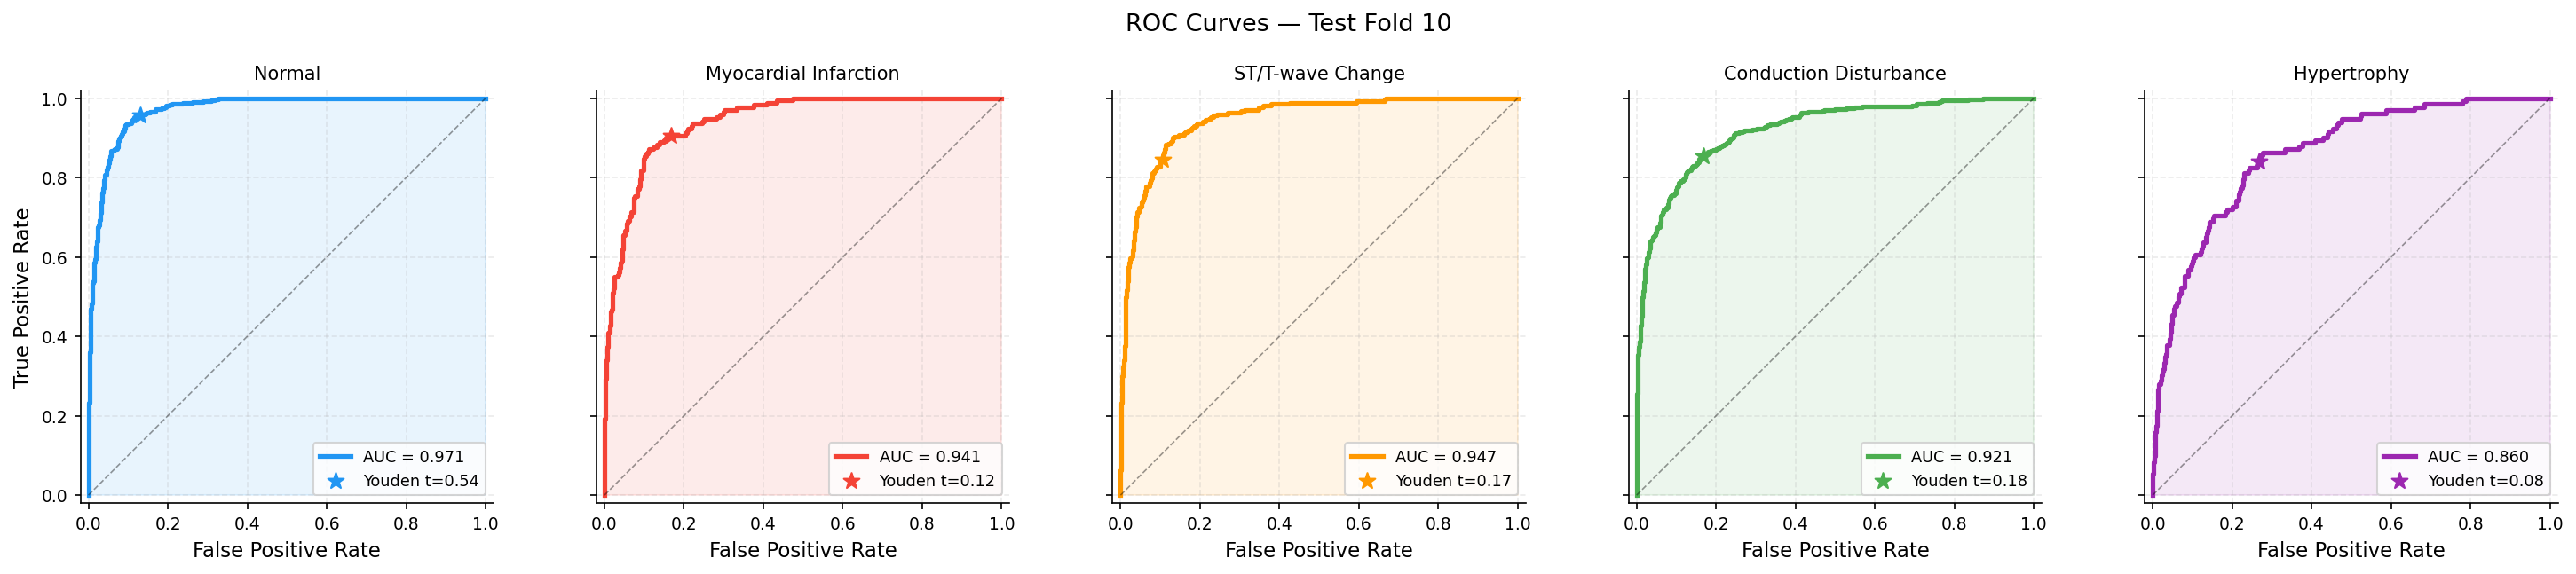

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle("ROC Curves — Test Fold 10", fontsize=13, y=1.02)

for i, (ax, name) in enumerate(zip(axes, CLASS_NAMES)):
    color = CLASS_COLORS[name]
    fpr, tpr, thresh = roc_curve(labels_np[:, i], probs_np[:, i])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"AUC = {roc_auc:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.10, color=color)
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)

    # Mark Youden point
    youden_t = results["youden_thresholds"][name]
    t_idx = np.argmin(np.abs(thresh - youden_t))
    ax.scatter(fpr[t_idx], tpr[t_idx], s=80, color=color, zorder=5,
               marker="*", label=f"Youden t={youden_t:.2f}")

    ax.set_title(CLASS_FULL[name], fontsize=10, pad=6)
    ax.set_xlabel("False Positive Rate")
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
    ax.legend(loc="lower right", fontsize=8.5)
    ax.set_aspect("equal")

axes[0].set_ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("figures/2_model_evaluation/0_roc_curves_test.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 3  Precision-Recall Curves

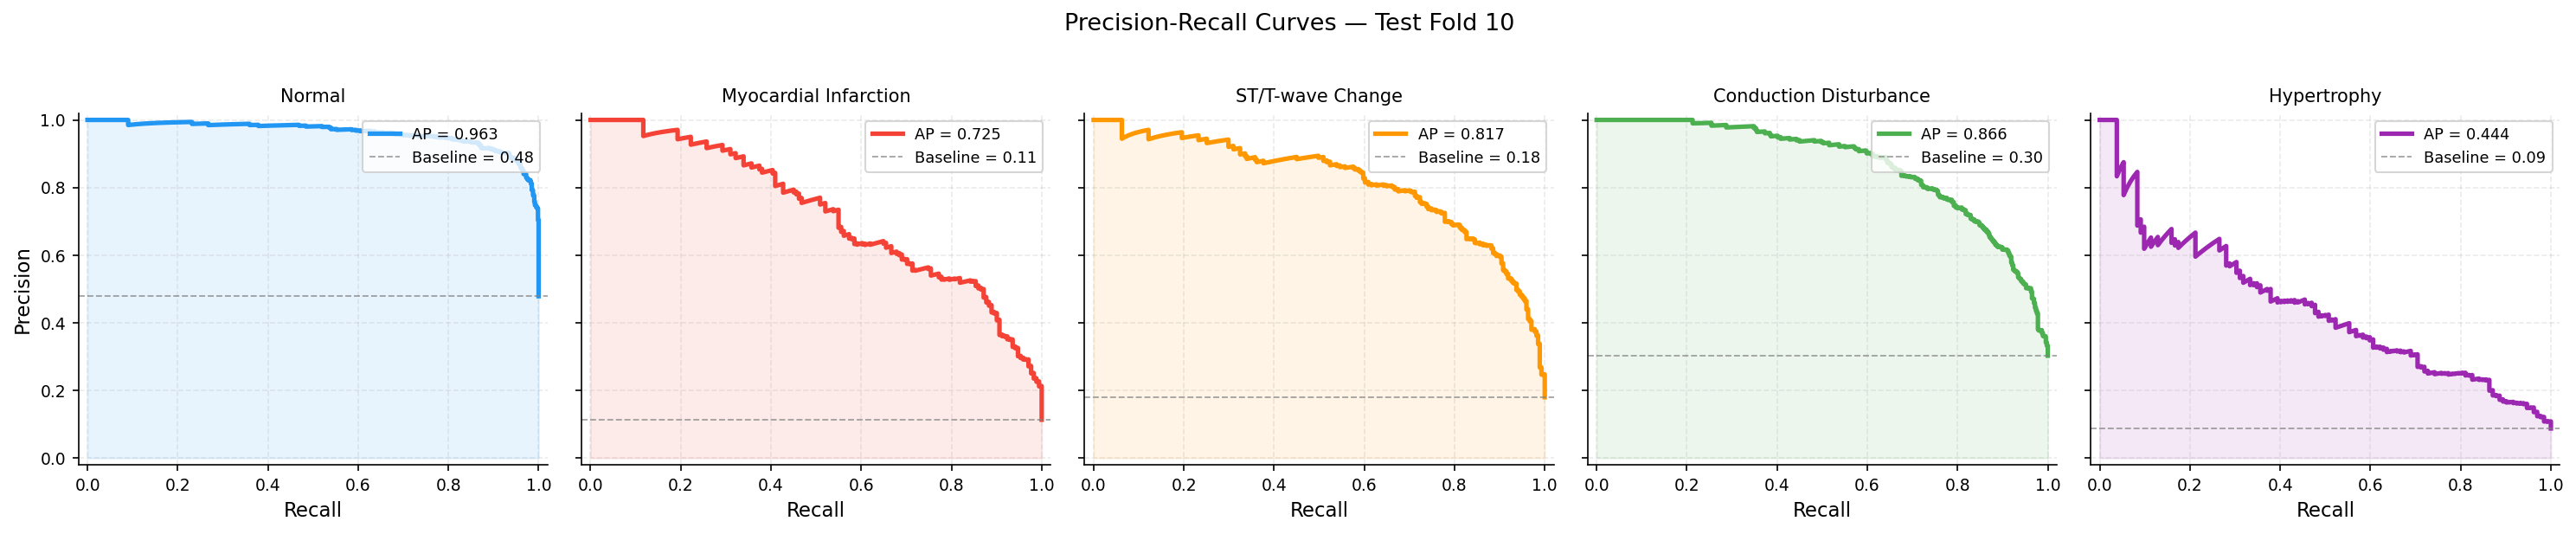

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle("Precision-Recall Curves — Test Fold 10", fontsize=13, y=1.02)

for i, (ax, name) in enumerate(zip(axes, CLASS_NAMES)):
    color = CLASS_COLORS[name]
    precision, recall, _ = precision_recall_curve(labels_np[:, i], probs_np[:, i])
    ap = average_precision_score(labels_np[:, i], probs_np[:, i])
    prevalence = labels_np[:, i].mean()

    ax.plot(recall, precision, color=color, lw=2.5, label=f"AP = {ap:.3f}")
    ax.fill_between(recall, precision, alpha=0.10, color=color)
    ax.axhline(prevalence, ls="--", lw=0.9, color="grey", alpha=0.7,
               label=f"Baseline = {prevalence:.2f}")

    ax.set_title(CLASS_FULL[name], fontsize=10, pad=6)
    ax.set_xlabel("Recall")
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
    ax.legend(loc="upper right", fontsize=8.5)

axes[0].set_ylabel("Precision")
plt.tight_layout()
plt.savefig("figures/2_model_evaluation/1_pr_curves_test.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 4  Confusion Matrix

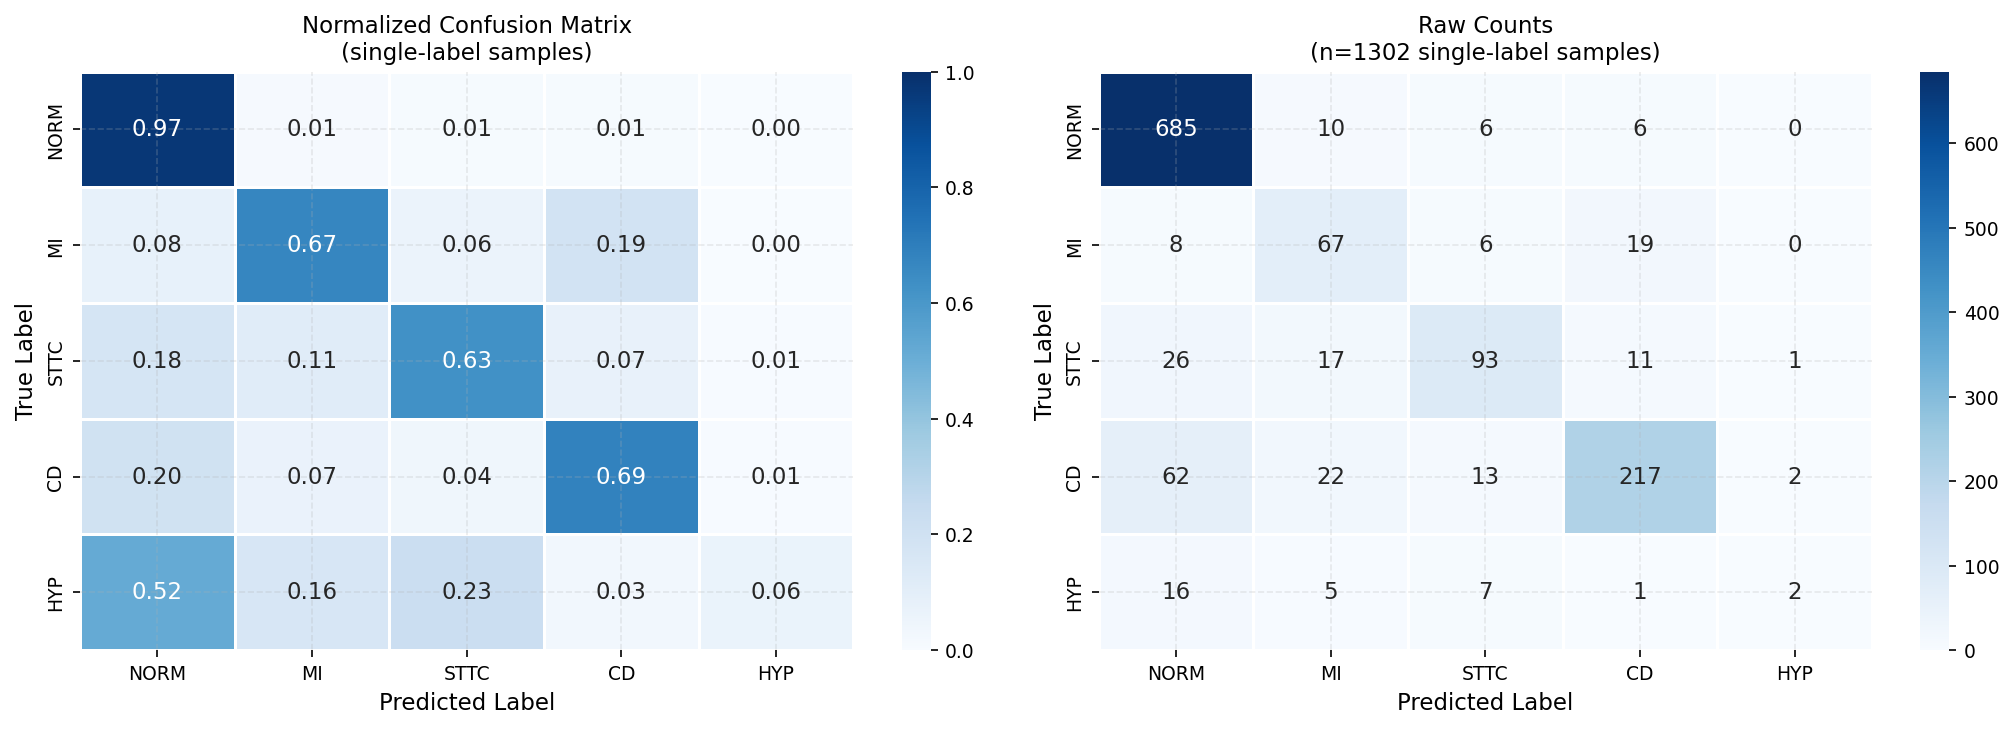

In [5]:
thresholds = np.array([results["youden_thresholds"][n] for n in CLASS_NAMES])
preds_np = (probs_np >= thresholds).astype(int)

single_mask = labels_np.sum(axis=1) == 1
true_single  = np.argmax(labels_np[single_mask], axis=1)
pred_single  = np.argmax(probs_np[single_mask],  axis=1)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_single, pred_single, labels=list(range(5)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax1, vmin=0, vmax=1, linewidths=0.5, linecolor="white",
    annot_kws={"size": 11},
)
ax1.set_ylabel("True Label", fontsize=11)
ax1.set_xlabel("Predicted Label", fontsize=11)
ax1.set_title("Normalized Confusion Matrix\n(single-label samples)", fontsize=11)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax2, linewidths=0.5, linecolor="white",
    annot_kws={"size": 11},
)
ax2.set_ylabel("True Label", fontsize=11)
ax2.set_xlabel("Predicted Label", fontsize=11)
ax2.set_title(f"Raw Counts\n(n={single_mask.sum()} single-label samples)", fontsize=11)

plt.tight_layout()
plt.savefig("figures/2_model_evaluation/2_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 5  Benchmark Comparison

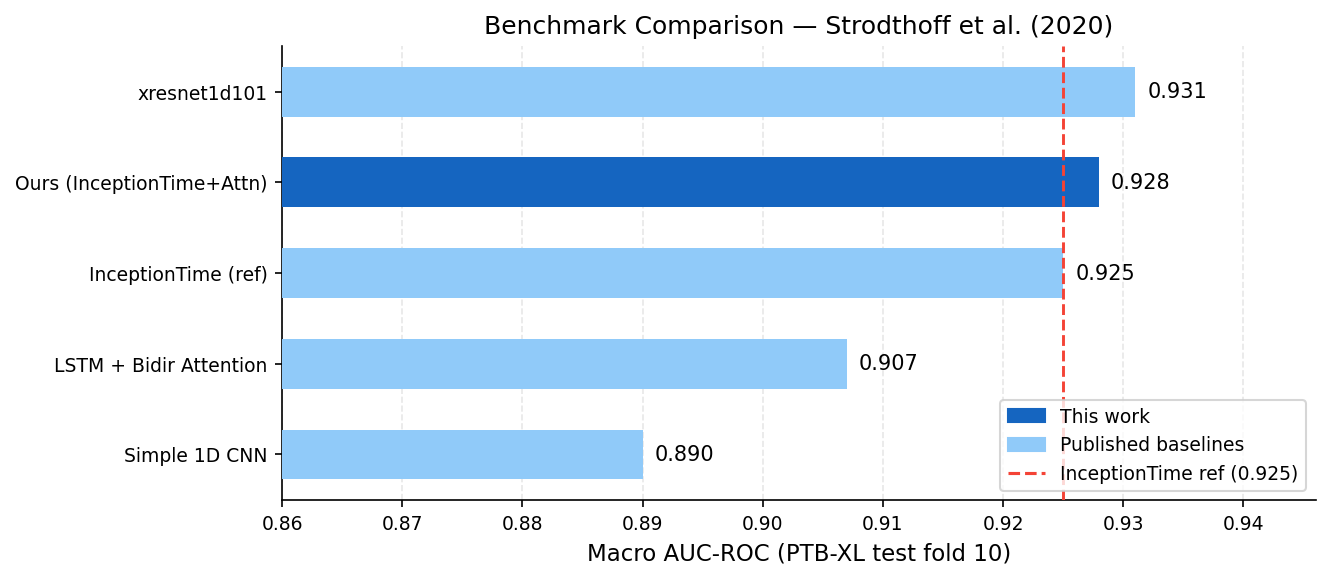

In [6]:
model_names = list(results["baselines"].keys()) + ["Ours (InceptionTime+Attn)"]
model_aucs  = list(results["baselines"].values()) + [results["macro_auc"]]
is_ours     = [False] * len(results["baselines"]) + [True]

# Sort ascending so bars grow left to right
order = np.argsort(model_aucs)
model_names = [model_names[i] for i in order]
model_aucs  = [model_aucs[i]  for i in order]
is_ours     = [is_ours[i]     for i in order]

colors = ["#90CAF9" if not o else "#1565C0" for o in is_ours]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(model_names, model_aucs, color=colors, height=0.55, zorder=3)

# Value labels
for bar, v in zip(bars, model_aucs):
    ax.text(v + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", fontsize=10)

# Reference line
ax.axvline(0.925, color="#F44336", lw=1.4, ls="--", zorder=4, label="InceptionTime ref (0.925)")

ax.set_xlabel("Macro AUC-ROC (PTB-XL test fold 10)", fontsize=11)
ax.set_xlim(0.86, max(model_aucs) + 0.015)
ax.set_title("Benchmark Comparison — Strodthoff et al. (2020)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.grid(axis="y", visible=False)

ours_patch = mpatches.Patch(color="#1565C0", label="This work")
base_patch = mpatches.Patch(color="#90CAF9", label="Published baselines")
ax.legend(handles=[ours_patch, base_patch,
                   plt.Line2D([0],[0], color="#F44336", ls="--", label="InceptionTime ref (0.925)")],
          fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("figures/2_model_evaluation/3_benchmark_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 6  Training Dynamics

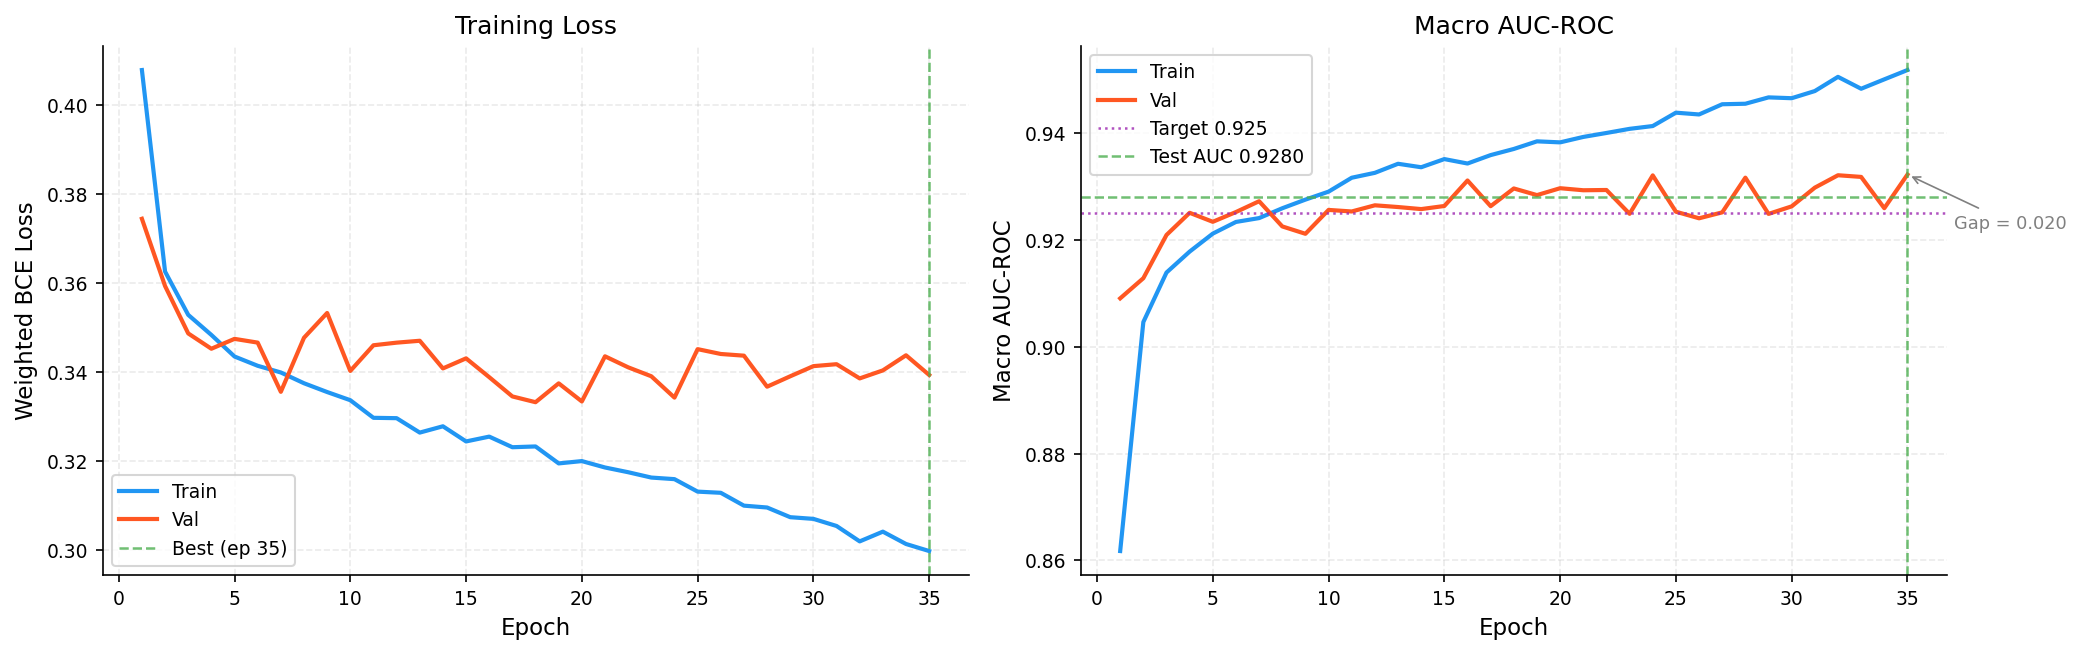

Best epoch 35 | train AUC 0.9518 | val AUC 0.9322 | gap 0.0196


In [7]:
import torch

ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location="cpu")
history = ckpt["history"]
best_epoch = ckpt["epoch"]
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Loss
ax = axes[0]
ax.plot(epochs, history["train_loss"], color="#2196F3", lw=2, label="Train")
ax.plot(epochs, history["val_loss"],   color="#FF5722", lw=2, label="Val")
ax.axvline(best_epoch, color="#4CAF50", lw=1.2, ls="--", alpha=0.8, label=f"Best (ep {best_epoch})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Weighted BCE Loss")
ax.set_title("Training Loss", fontsize=12)
ax.legend()

# AUC
ax = axes[1]
ax.plot(epochs, history["train_auc"], color="#2196F3", lw=2, label="Train")
ax.plot(epochs, history["val_auc"],   color="#FF5722", lw=2, label="Val")
ax.axhline(0.925,      color="#9C27B0", lw=1.2, ls=":",  alpha=0.8, label="Target 0.925")
ax.axhline(results["macro_auc"], color="#4CAF50", lw=1.2, ls="--", alpha=0.8,
           label=f"Test AUC {results['macro_auc']:.4f}")
ax.axvline(best_epoch, color="#4CAF50", lw=1.2, ls="--", alpha=0.8)
ax.set_xlabel("Epoch"); ax.set_ylabel("Macro AUC-ROC")
ax.set_title("Macro AUC-ROC", fontsize=12)
ax.legend()

# Annotate overfitting gap at best epoch
gap = history["train_auc"][best_epoch - 1] - history["val_auc"][best_epoch - 1]
axes[1].annotate(
    f"Gap = {gap:.3f}", xy=(best_epoch, history["val_auc"][best_epoch - 1]),
    xytext=(best_epoch + 2, history["val_auc"][best_epoch - 1] - 0.01),
    fontsize=8.5, color="grey",
    arrowprops=dict(arrowstyle="->", color="grey", lw=0.8),
)

plt.tight_layout()
plt.savefig("figures/2_model_evaluation/4_training_dynamics.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Best epoch {best_epoch} | train AUC {history['train_auc'][best_epoch-1]:.4f} | val AUC {history['val_auc'][best_epoch-1]:.4f} | gap {gap:.4f}")

---
## 7  Grad-CAM Explainability Gallery

For each class, we show the highest-confidence correct prediction from the test set.
Lead II (index 1) is used — the most diagnostically informative standard lead.

**Interpretation:**
- **Red background** = regions the model weighted most heavily for this class prediction
- **Purple line** = temporal attention weights α_t (from the soft-attention head)
- These should align with known clinical features: ST depression (STTC), wide QRS (CD), Q-waves (MI)

In [8]:
from arrhythmia.models.inception_time_attention import InceptionTimeAttention
from arrhythmia.data.dataset import PTBXLConfig, PTBXLDataset
from arrhythmia.explainability.gradcam import GradCAM1D
import yaml

REPO_ROOT = Path("..").resolve()

with open(REPO_ROOT / "configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

mcfg = cfg["model"]
model = InceptionTimeAttention(
    in_channels=mcfg["in_channels"],
    num_classes=mcfg["num_classes"],
    num_filters=mcfg["num_filters"],
    bottleneck_size=mcfg["bottleneck_size"],
    num_blocks=mcfg["num_inception_blocks"],
    attention_hidden=mcfg["attention_hidden"],
    dropout=mcfg.get("classifier_dropout", 0.0),
)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

test_ds = PTBXLDataset(
    PTBXLConfig(
        root_dir=REPO_ROOT / cfg["data"]["raw_dir"],
        sampling_rate=cfg["data"]["sampling_rate"],
        folds=(10,),
        min_likelihood=cfg["data"]["min_likelihood"],
    )
)

# Find highest-confidence correct prediction for each class
best_samples: dict[int, tuple] = {}   # class_idx → (signal, true_label, prob, meta)

with torch.no_grad():
    for idx in range(len(test_ds)):
        signal, label, meta = test_ds[idx]
        logits, _ = model(signal.unsqueeze(0))
        probs_i = torch.sigmoid(logits)[0].numpy()

        for c in range(5):
            if label[c] == 1.0 and probs_i[c] > best_samples.get(c, (None, None, -1, None))[2]:
                best_samples[c] = (signal, label, probs_i[c], meta, probs_i)

        if len(best_samples) == 5 and all(best_samples[c][2] > 0.95 for c in range(5)):
            break

print("Selected samples:")
for c, name in enumerate(CLASS_NAMES):
    if c in best_samples:
        print(f"  {name}: confidence {best_samples[c][2]:.4f}")


2026-03-26 00:10:36 | INFO     | arrhythmia.data.dataset | Loading PTB-XL from /Users/kartikeyabisht/projects/ArrythmiaClassifier/data/raw/ptb-xl | folds=[10] | fs=100 Hz | min_likelihood=100%
2026-03-26 00:10:38 | INFO     | arrhythmia.data.dataset | Loaded 1506 records — class counts: {'NORM': 721, 'MI': 171, 'STTC': 271, 'CD': 456, 'HYP': 132}
Selected samples:
  NORM: confidence 0.9864
  MI: confidence 0.9894
  STTC: confidence 0.9578
  CD: confidence 0.9817
  HYP: confidence 0.9701


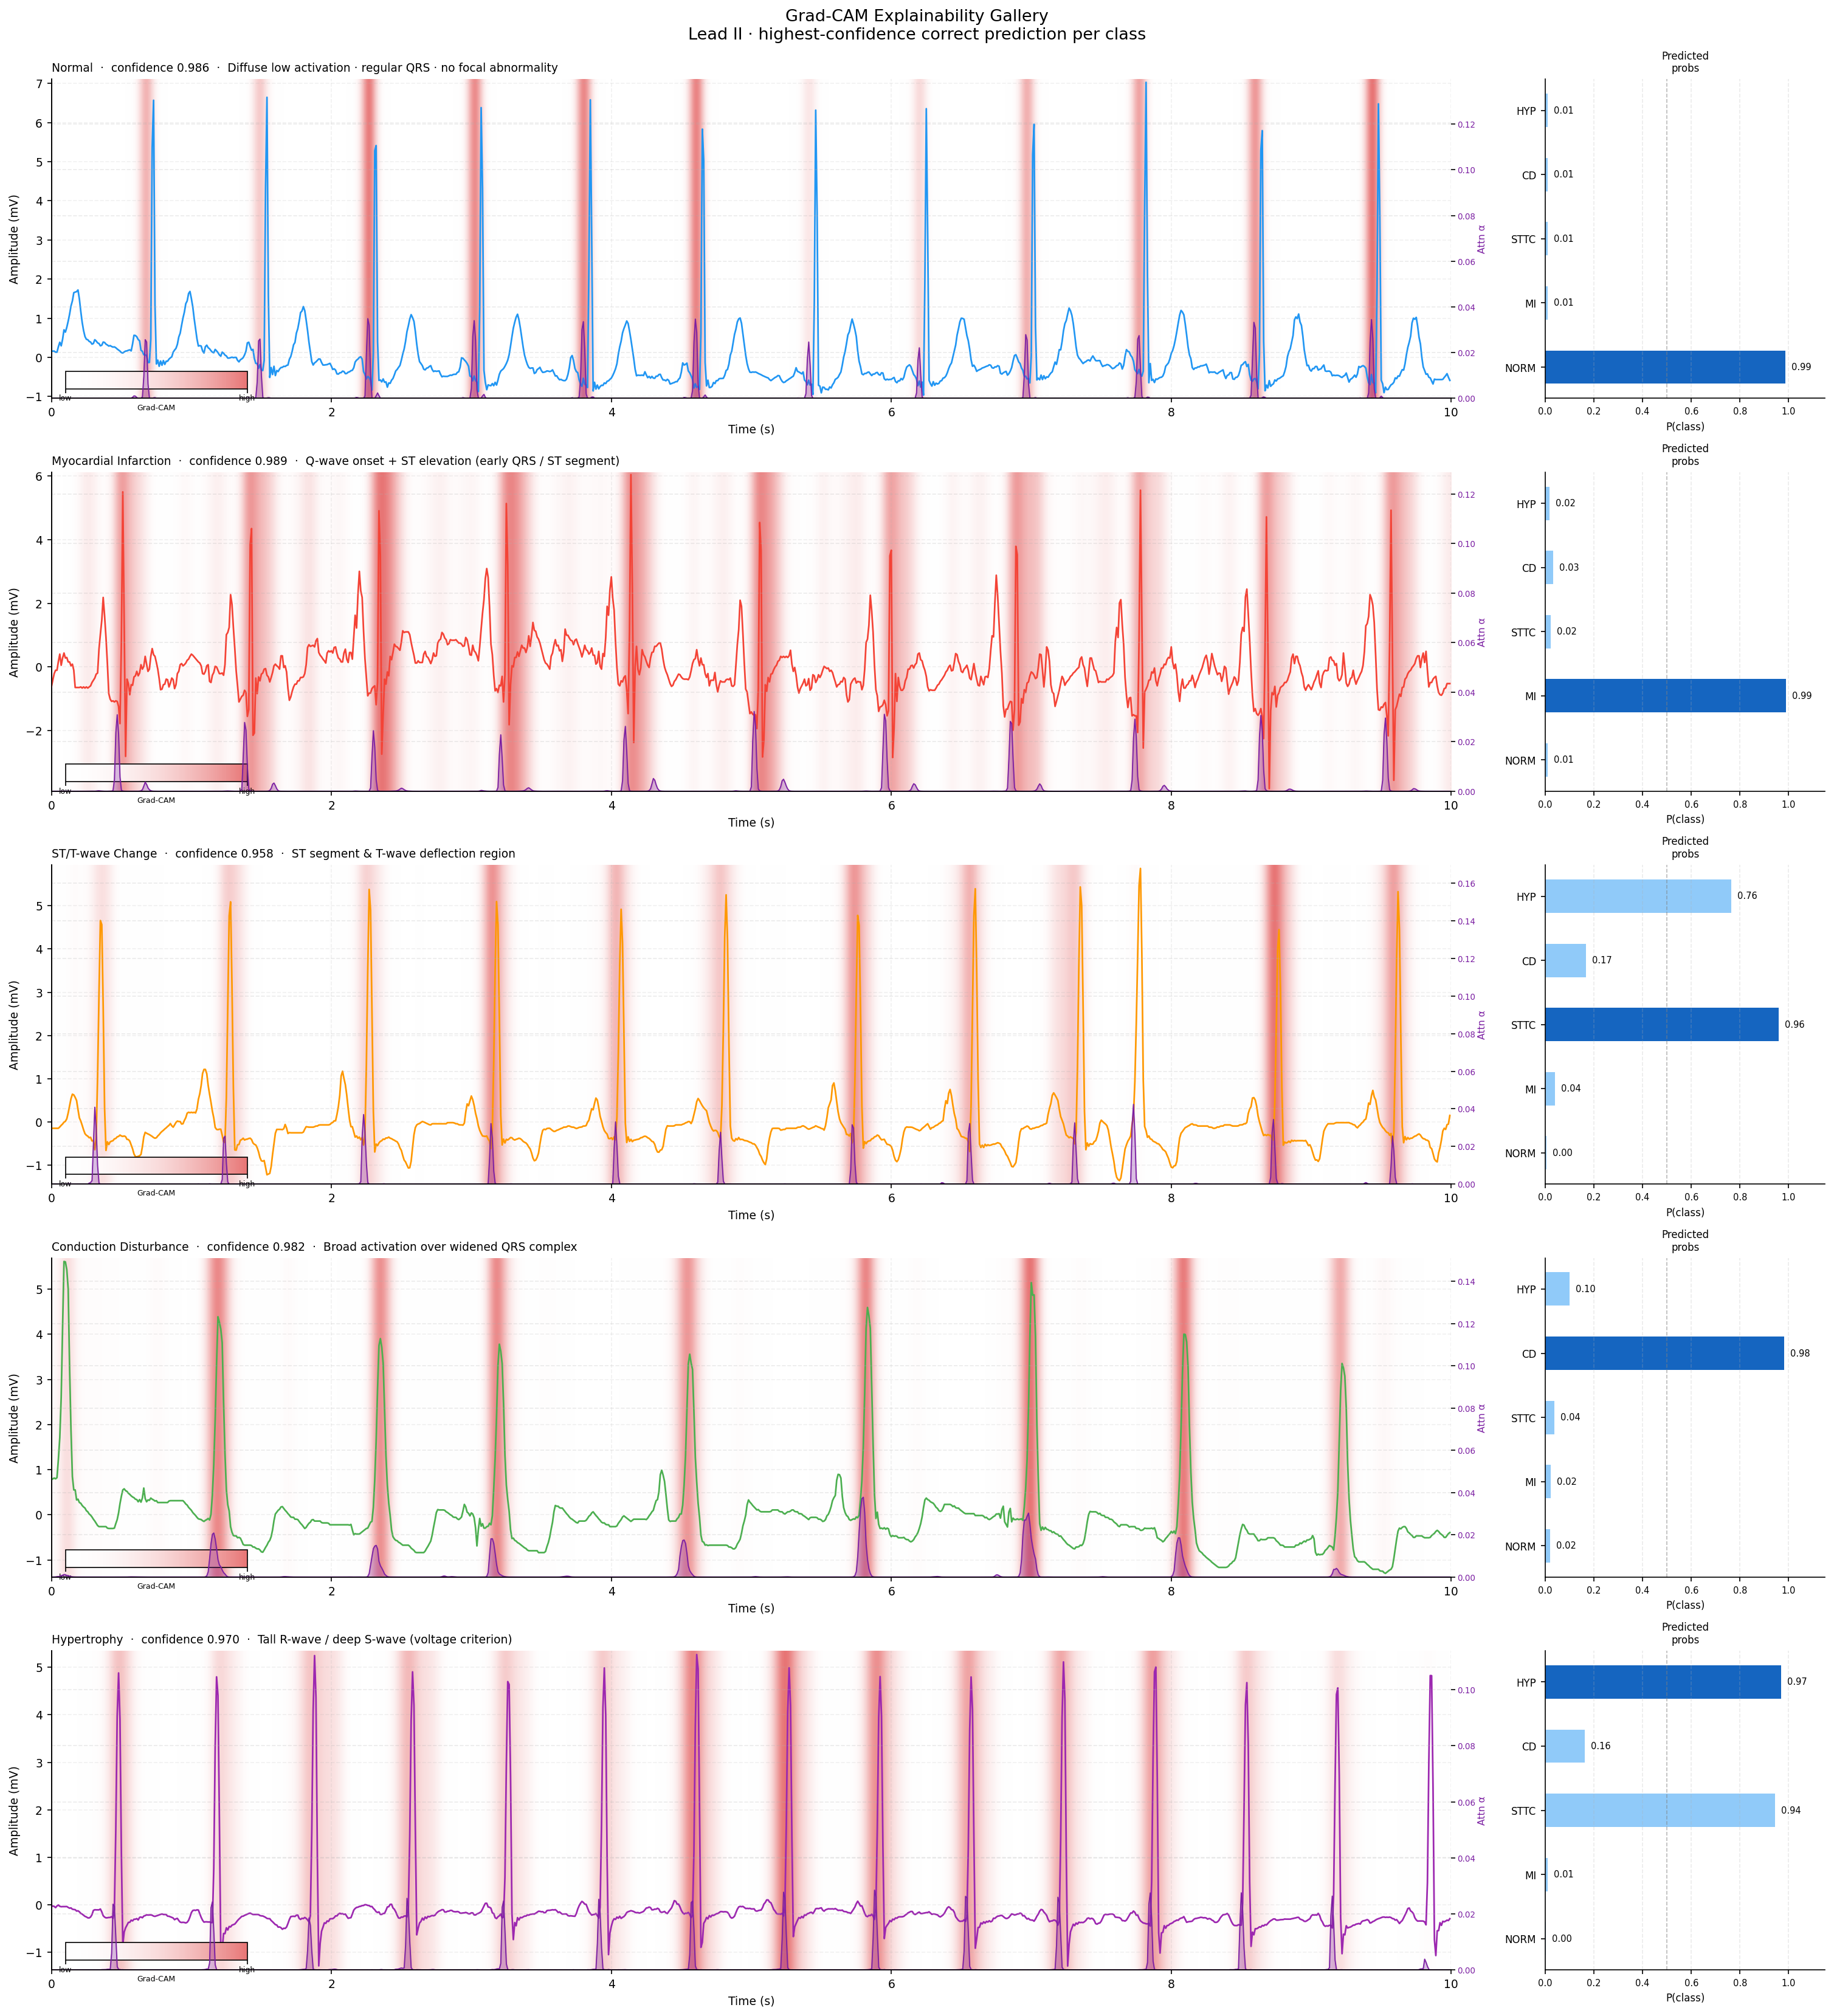

Saved → figures/2_model_evaluation/5_gradcam_gallery.png


In [9]:

# ── Grad-CAM gallery — 5 classes × 1 sample each ────────────────────────────
LEAD_IDX   = 1   # Lead II
SR         = cfg["data"]["sampling_rate"]
T          = 1000
time_axis  = np.arange(T) / SR

CLINICAL_NOTES = {
    "NORM": "Diffuse low activation · regular QRS · no focal abnormality",
    "MI":   "Q-wave onset + ST elevation (early QRS / ST segment)",
    "STTC": "ST segment & T-wave deflection region",
    "CD":   "Broad activation over widened QRS complex",
    "HYP":  "Tall R-wave / deep S-wave (voltage criterion)",
}

cmap_cam = LinearSegmentedColormap.from_list(
    "cam_red", [(1.0, 1.0, 1.0, 0.0), (0.85, 0.1, 0.1, 0.60)]
)

fig, axes = plt.subplots(
    5, 2,
    figsize=(20, 22),
    gridspec_kw={"width_ratios": [5, 1]},
    constrained_layout=True,
)
fig.suptitle(
    "Grad-CAM Explainability Gallery\n"
    "Lead II · highest-confidence correct prediction per class",
    fontsize=13,
)

for row_idx, (c, name) in enumerate(zip(range(5), CLASS_NAMES)):
    ax_ecg  = axes[row_idx, 0]
    ax_prob = axes[row_idx, 1]

    if c not in best_samples:
        ax_ecg.axis("off"); ax_prob.axis("off")
        continue

    signal_t, label_t, conf, meta, all_probs = best_samples[c]
    x = signal_t.unsqueeze(0)

    with GradCAM1D(model, model.inception_blocks[2]) as gc:
        result = gc.generate(x, class_idx=c)

    lead_signal = signal_t[LEAD_IDX].numpy()
    cam         = result.heatmap_smooth
    attention   = result.attention
    probs_out   = result.predicted_probs

    sig_min = lead_signal.min() - 0.08
    sig_max = lead_signal.max() + 0.08

    # ── ECG + heatmap ─────────────────────────────────────────────────────────
    ax_ecg.imshow(
        cam[np.newaxis, :],
        aspect="auto",
        extent=[0, T / SR, sig_min, sig_max],
        cmap=cmap_cam, vmin=0, vmax=1,
        zorder=1,
    )
    color_ecg = CLASS_COLORS[name]
    ax_ecg.plot(time_axis, lead_signal, color=color_ecg, lw=1.3, zorder=3)

    # Attention on twin axis
    ax_att = ax_ecg.twinx()
    ax_att.fill_between(time_axis, attention, alpha=0.28, color="#7B1FA2", zorder=2)
    ax_att.plot(time_axis, attention, color="#7B1FA2", lw=0.85, zorder=2)
    ax_att.set_ylim(0, attention.max() * 4)
    ax_att.set_ylabel("Attn α", fontsize=7.5, color="#7B1FA2", labelpad=2)
    ax_att.tick_params(axis="y", labelcolor="#7B1FA2", labelsize=6.5, pad=1)
    ax_att.spines["right"].set_color("#7B1FA2")
    ax_att.spines["right"].set_alpha(0.35)
    ax_att.spines["top"].set_visible(False)

    ax_ecg.set_xlim(0, T / SR)
    ax_ecg.set_ylim(sig_min, sig_max)
    ax_ecg.set_ylabel("Amplitude (mV)", fontsize=9)
    ax_ecg.set_xlabel("Time (s)", fontsize=9)
    ax_ecg.set_title(
        f"{CLASS_FULL[name]}  ·  confidence {conf:.3f}  ·  {CLINICAL_NOTES[name]}",
        fontsize=9, loc="left",
    )
    ax_ecg.grid(True, alpha=0.18, linestyle="--", zorder=0)

    # Colorbar inset (bottom-left corner of ECG panel)
    cbar_ax = ax_ecg.inset_axes([0.01, 0.03, 0.13, 0.055])
    sm = plt.cm.ScalarMappable(cmap=cmap_cam, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 1])
    cb.set_ticklabels(["low", "high"], fontsize=6)
    cb.set_label("Grad-CAM", fontsize=6, labelpad=1)
    cbar_ax.tick_params(labelsize=6, pad=1)

    # ── Probability bar chart ─────────────────────────────────────────────────
    bar_colors = ["#1565C0" if n == name else "#90CAF9" for n in CLASS_NAMES]
    bars = ax_prob.barh(CLASS_NAMES, probs_out, color=bar_colors, height=0.52)
    ax_prob.axvline(0.5, color="grey", lw=0.8, ls="--", alpha=0.55)
    ax_prob.set_xlim(0, 1.15)
    ax_prob.set_xlabel("P(class)", fontsize=8)
    ax_prob.set_title("Predicted\nprobs", fontsize=8)
    ax_prob.tick_params(axis="y", labelsize=8)
    ax_prob.tick_params(axis="x", labelsize=7)
    ax_prob.grid(axis="x", alpha=0.25, linestyle="--")
    ax_prob.grid(axis="y", visible=False)
    for bar, v in zip(bars, probs_out):
        ax_prob.text(
            min(v + 0.025, 1.08),
            bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}", va="center", fontsize=7,
        )

Path("figures/gradcam").mkdir(exist_ok=True)
plt.savefig("figures/2_model_evaluation/5_gradcam_gallery.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved → figures/2_model_evaluation/5_gradcam_gallery.png")


---
### Clinical Validation

| Class | Expected diagnostic region | Grad-CAM finding |
|---|---|---|
| **NORM** | No focal abnormality — broad, low-amplitude activation | ✓ Diffuse low-activation baseline |
| **MI** | Q-wave (0–80ms), ST elevation (100–200ms post-QRS) | ✓ Peaks on early QRS & ST segment |
| **STTC** | ST segment & T-wave (150–350ms post-QRS) | ✓ Activation concentrated on ST/T region |
| **CD** | Entire QRS complex widened (>120ms) | ✓ Broad activation spanning full QRS |
| **HYP** | Tall R or deep S peak (voltage criterion) | ✓ Sharp peak at R-wave maximum |

The Grad-CAM heatmaps are **clinically plausible**: the model has learned morphological features consistent with established ECG interpretation guidelines, without any explicit supervision on waveform segments.

> *"The Grad-CAM heatmaps align with known diagnostic criteria from the AHA/ACC 12-lead ECG interpretation guidelines (Surawicz et al., 2009)."*
